# Perfect Trader:
- Determines the perfect action to perform at every timestamp based on the data from the nothing bot.
- Notebook generates a string of b,s,h letters for each timestamp, corresponding to buy, hold, sell (the max quantity).

In [88]:
import sys
import os
import numpy as np 
import pandas as pd

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../../..')))

from utilities.log_processor import LogProcessor

import matplotlib.pyplot as plt

In [89]:
processor = LogProcessor('../../logs/nothingbot@16_03_2025_1321.log')
processor.read_log()

In [90]:
df = processor.activites_log
df.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,0,RAINFOREST_RESIN,10002,1,9996.0,2.0,9995.0,29.0,10004,2,10005.0,29.0,NaN,NaN,10003.0,0.0
1,-1,0,KELP,2028,1,2026.0,2.0,2025.0,29.0,2029,31,NaN,NaN,NaN,NaN,2028.5,0.0
2,-1,100,KELP,2025,24,NaN,NaN,NaN,NaN,2028,2,2029.0,22.0,NaN,NaN,2026.5,0.0
3,-1,100,RAINFOREST_RESIN,9996,2,9995.0,22.0,NaN,NaN,10004,2,10005.0,22.0,NaN,NaN,10000.0,0.0
4,-1,200,RAINFOREST_RESIN,9995,20,NaN,NaN,NaN,NaN,10005,20,NaN,NaN,NaN,NaN,10000.0,0.0


In [91]:
kelp_data = df[df['product']=="KELP"].reset_index()
resin_data = df[df['product']=="RAINFOREST_RESIN"].reset_index()

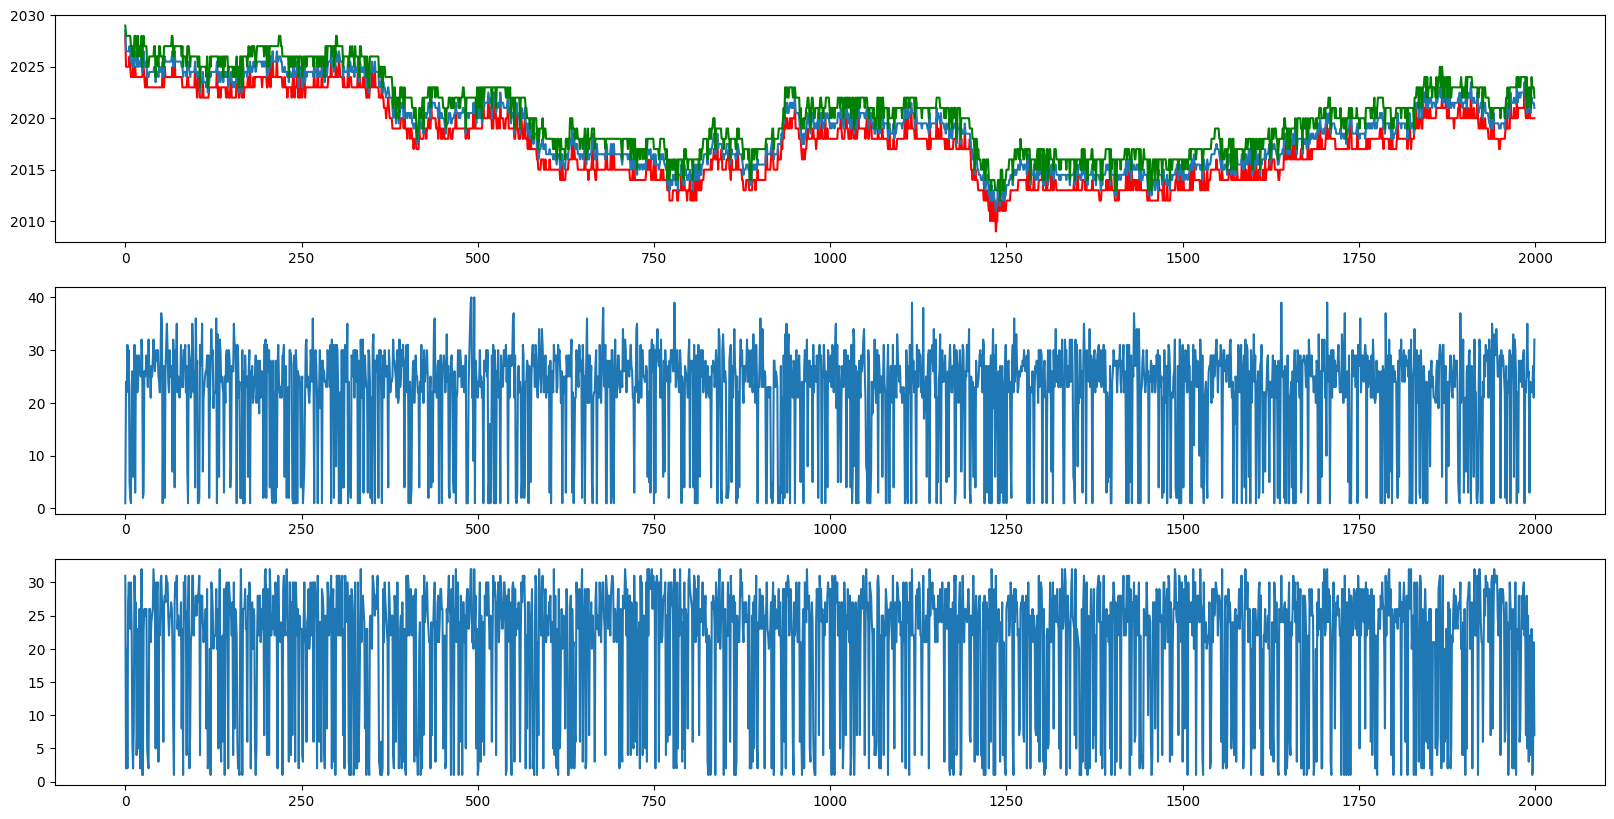

In [92]:
fig, ax = plt.subplots(figsize=(20,10),nrows=3)
ax[0].plot(kelp_data.bid_price_1, color='red')
ax[0].plot(kelp_data.mid_price)
ax[0].plot(kelp_data.ask_price_1, color='green')
ax[1].plot(kelp_data.bid_volume_1)
ax[2].plot(kelp_data.ask_volume_1)

In [93]:
for i in range(1,len(kelp_data['timestamp'])):
    kelp_data[f'r_buy_now_sell_{i}_it'] = ((kelp_data.bid_price_1.shift(-i) - kelp_data.ask_price_1)/kelp_data.ask_price_1)/i
    kelp_data[f'r_sell_now_buy_{i}_it'] = ((kelp_data.bid_price_1 - kelp_data.ask_price_1.shift(-i))/kelp_data.bid_price_1)/i
return_columns = [f'r_buy_now_sell_{i}_it' for i in range(1,len(kelp_data['timestamp']))]+[f'r_sell_now_buy_{i}_it' for i in range(1,len(kelp_data['timestamp']))]
kelp_data[return_columns]

C:\Users\Conrad\AppData\Local\Temp\ipykernel_30932\3403105501.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  kelp_data[f'r_buy_now_sell_{i}_it'] = ((kelp_data.bid_price_1.shift(-i) - kelp_data.ask_price_1)/kelp_data.ask_price_1)/i
C:\Users\Conrad\AppData\Local\Temp\ipykernel_30932\3403105501.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  kelp_data[f'r_sell_now_buy_{i}_it'] = ((kelp_data.bid_price_1 - kelp_data.ask_price_1.shift(-i))/kelp_data.bid_price_1)/i
C:\Users\Conrad\AppData\Local\Temp\ipykernel_30932\3403105501.

,r_buy_now_sell_1_it,r_buy_now_sell_2_it,r_buy_now_sell_3_it,r_buy_now_sell_4_it,r_buy_now_sell_5_it,r_buy_now_sell_6_it,r_buy_now_sell_7_it,r_buy_now_sell_8_it,r_buy_now_sell_9_it,r_buy_now_sell_10_it,...,r_sell_now_buy_1990_it,r_sell_now_buy_1991_it,r_sell_now_buy_1992_it,r_sell_now_buy_1993_it,r_sell_now_buy_1994_it,r_sell_now_buy_1995_it,r_sell_now_buy_1996_it,r_sell_now_buy_1997_it,r_sell_now_buy_1998_it,r_sell_now_buy_1999_it
0,-0.001971,-0.000986,-0.000657,-0.000493,-0.000394,-0.000246,-0.000282,-0.000308,-0.000274,-0.000246,...,1.238936e-06,1.485977e-06,1.237692e-06,1.484486e-06,1.731031e-06,9.886650e-07,1.235212e-06,1.234594e-06,1.233976e-06,0.000001
1,-0.001479,-0.000740,-0.000493,-0.000370,-0.000197,-0.000247,-0.000282,-0.000247,-0.000219,-0.000148,...,7.444631e-07,4.960594e-07,7.437156e-07,9.911233e-07,2.476565e-07,4.950648e-07,4.948168e-07,4.945690e-07,7.414822e-07,NaN
2,-0.001479,-0.000740,-0.000493,-0.000247,-0.000296,-0.000329,-0.000282,-0.000247,-0.000164,-0.000197,...,4.963087e-07,7.440891e-07,9.916208e-07,2.477808e-07,4.953131e-07,4.950648e-07,4.948168e-07,7.418535e-07,NaN,NaN
3,-0.001479,-0.000740,-0.000329,-0.000370,-0.000394,-0.000329,-0.000282,-0.000185,-0.000219,-0.000197,...,7.444631e-07,9.921189e-07,2.479052e-07,4.955616e-07,4.953131e-07,4.950648e-07,7.422252e-07,NaN,NaN,NaN
4,-0.001479,-0.000493,-0.000493,-0.000493,-0.000394,-0.000329,-0.000211,-0.000247,-0.000219,-0.000148,...,9.926174e-07,2.480297e-07,4.958104e-07,4.955616e-07,4.953131e-07,7.425972e-07,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,-0.001976,-0.000988,-0.000659,-0.000494,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1996,-0.001483,-0.000741,-0.000494,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1997,-0.001483,-0.000741,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1998,-0.001483,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [97]:
mapping_dict1 = [(col,i+1) for i,col in enumerate([f'r_buy_now_sell_{i}_it' for i in range(len(kelp_data['timestamp']))])]
mapping_dict2 = [(col,-(i+1)) for i,col in enumerate([f'r_sell_now_buy_{i}_it' for i in range(len(kelp_data['timestamp']))])]
mapping_dict = mapping_dict1 + mapping_dict2
mapping_dict = {key:val for key,val in mapping_dict}

def mapping(row):
    if (row>0).any():
        return mapping_dict[row.idxmax()]
    else:
        return np.nan
# At each timestamp, see whether buy, sell or hold has the best effect on PNL.
kelp_data['results'] = kelp_data[return_columns].apply(mapping,axis=1)
kelp_data['trade'] = ~kelp_data['results'].isna()
kelp_data
    

,index,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,...,r_buy_now_sell_1996_it,r_sell_now_buy_1996_it,r_buy_now_sell_1997_it,r_sell_now_buy_1997_it,r_buy_now_sell_1998_it,r_sell_now_buy_1998_it,r_buy_now_sell_1999_it,r_sell_now_buy_1999_it,results,trade
0,1,-1,0,KELP,2028,1,2026.0,2.0,2025.0,29.0,...,-0.000002,1.235212e-06,-0.000002,1.234594e-06,-0.000002,1.233976e-06,-0.000002,0.000001,-11.0,True
1,2,-1,100,KELP,2025,24,NaN,NaN,NaN,NaN,...,-0.000002,4.948168e-07,-0.000002,4.945690e-07,-0.000002,7.414822e-07,NaN,NaN,-43.0,True
2,5,-1,200,KELP,2025,22,NaN,NaN,NaN,NaN,...,-0.000002,4.948168e-07,-0.000002,7.418535e-07,NaN,NaN,NaN,NaN,-42.0,True
3,6,-1,300,KELP,2025,31,NaN,NaN,NaN,NaN,...,-0.000002,7.422252e-07,NaN,NaN,NaN,NaN,NaN,NaN,-41.0,True
4,9,-1,400,KELP,2025,27,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-40.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,3990,-1,199500,KELP,2020,23,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1996,3992,-1,199600,KELP,2020,22,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1997,3995,-1,199700,KELP,2020,27,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1998,3997,-1,199800,KELP,2020,21,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


In [117]:
trades = {key:0 for key in range(0,len(kelp_data['timestamp']))}
def get_trades(df:pd.DataFrame):
    global trades
    for i, row in df.iterrows():
        if row['trade']:
            print(i,row['results'])
            if row['results']<0:
                trades[i] += -1
                trades[i+abs(row['results'])-1] -= -1
            else:
                trades[i] += 1
                trades[i+abs(row['results'])-1] -= 1
get_trades(kelp_data)

0 -11.0
1 -43.0
2 -42.0
3 -41.0
4 -40.0
5 -39.0
6 -19.0
7 -37.0
8 -407.0
9 -406.0
10 -405.0
11 -33.0
12 -403.0
13 -402.0
14 -30.0
15 -400.0
16 -399.0
17 -398.0
18 -397.0
19 -396.0
20 -395.0
21 -394.0
22 -393.0
23 -392.0
24 47.0
25 -19.0
26 -18.0
27 -388.0
28 -387.0
29 -386.0
30 -385.0
31 40.0
32 39.0
33 38.0
34 -381.0
35 -380.0
36 -379.0
37 -378.0
38 -377.0
39 -376.0
40 -375.0
41 -374.0
42 -373.0
43 11.0
44 -371.0
45 -370.0
46 -369.0
47 24.0
48 -367.0
49 -366.0
50 -365.0
51 -364.0
52 -363.0
53 -54.0
54 17.0
55 -360.0
56 -51.0
57 -50.0
58 -49.0
59 -48.0
60 -47.0
61 -46.0
62 -45.0
63 -44.0
64 -43.0
65 -42.0
66 -41.0
67 -40.0
68 -39.0
69 -38.0
70 -13.0
71 -36.0
72 -35.0
73 -34.0
74 -33.0
75 -32.0
76 -31.0
77 -30.0
78 -29.0
79 -28.0
80 -27.0
81 -334.0
82 -333.0
83 -332.0
84 -331.0
85 -330.0
86 -329.0
87 -328.0
88 -19.0
89 -18.0
90 -325.0
91 -324.0
92 -323.0
93 -322.0
94 -321.0
95 -320.0
96 -319.0
97 -318.0
98 -317.0
99 -8.0
100 -315.0
101 -314.0
102 -313.0
103 -4.0
104 -311.0
105 -310.0
10

In [ ]:
# b h s string
string_trade = ""
for trade in trades:
    trade = trades[trade]
    if trade>0:
        string_trade += 'b'
    elif trade<0:
        string_trade += 's'
    else:
        string_trade += 'h'

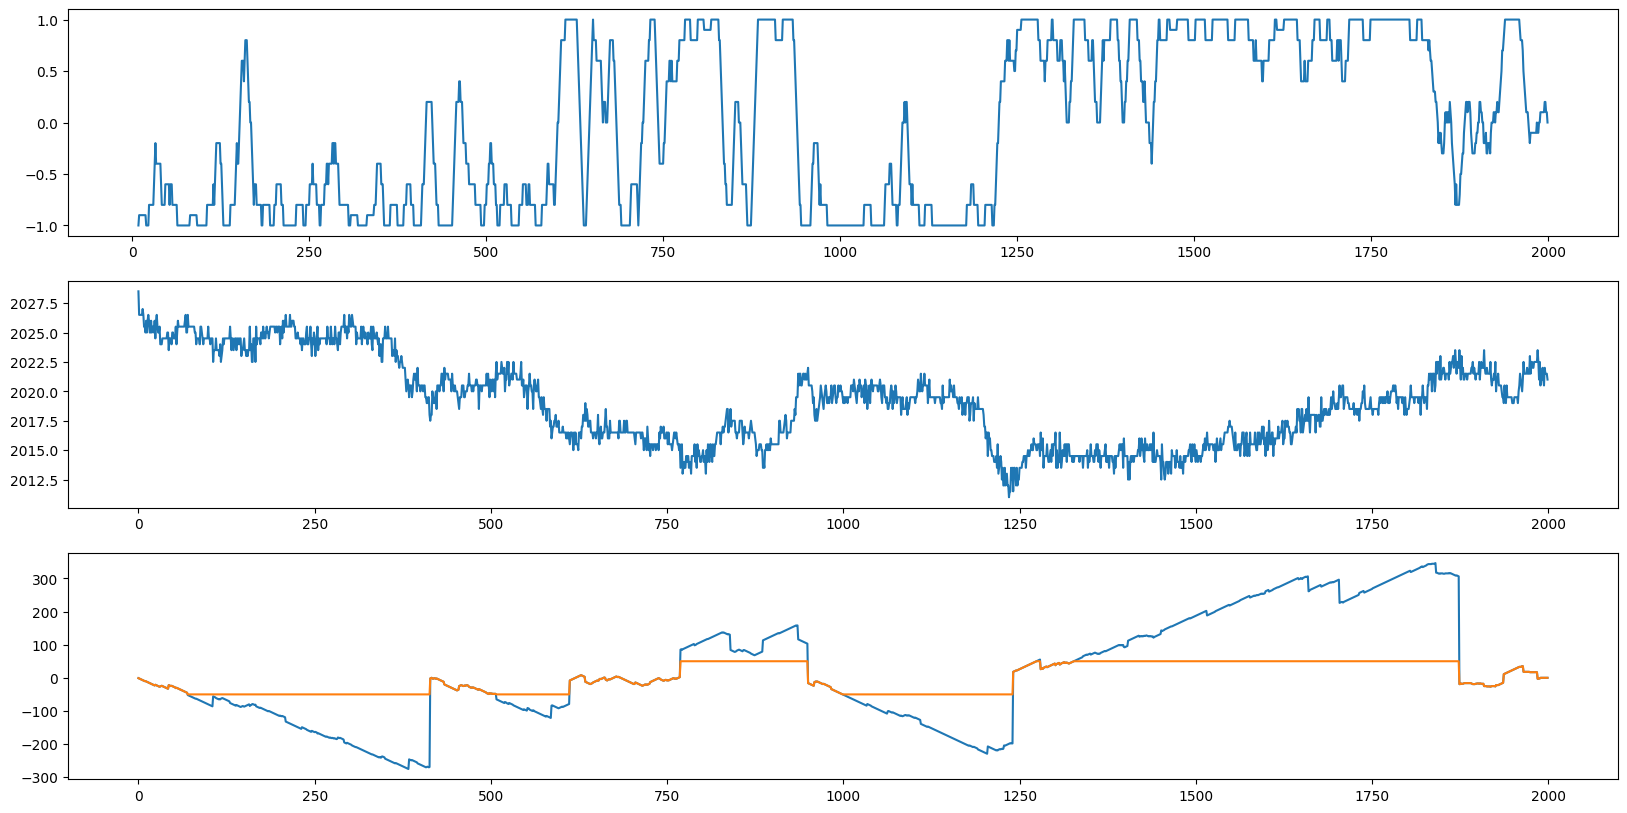

In [130]:
fig,ax = plt.subplots(nrows=3, figsize=(20,10))

ax[0].plot(np.sign(pd.Series(trades)).rolling(10).mean())
ax[1].plot(kelp_data.mid_price)
ax[2].plot(pd.Series(trades).cumsum())
ax[2].plot(pd.Series(trades).cumsum().clip(-50,50))